# GDL 1 uzduotis, 1 dalis

Variantas: **5**  
Pateiktos architekturos: **Variantas 2**, **Variantas 7**, **Variantas 8**

Notebooke pateikiamas:

- duomenu rinkinio paruosimas;
- klasiu disbalanso ivertinimas;
- triju nurodytu CNN architekturu apmokymas ir palyginimas;
- mano pasiulyta architektura;
- mazesnes duomenu imties tyrimas su `Stratified K-Fold`;
- galutines isvados lietuviu kalba.


In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "task1"
TABLES_DIR = ARTIFACTS_DIR / "tables"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
RESULTS = json.loads((ARTIFACTS_DIR / "results.json").read_text(encoding="utf-8"))

pd.options.display.float_format = lambda value: f"{value:.4f}"


## Uzdavinio nustatymas

Is pradinio duomenu rinkinio paliktos tik tavo variantui priklausancios klases:

| Nauja klase | Pavadinimas | Originalios klases |
| --- | --- | --- |
| 0 | Outerwear | 2, 3, 4 |
| 1 | Shirts | 0, 6 |
| 2 | Pants | 1 |
| 3 | Low-top shoes | 5, 7 |
| 4 | Accessories | 8 |

Klasiu is originalaus rinkinio, kuriu lenteleje nera, buvo atsisakyta.

Duomenu skaidymas atliktas **stratified** budu, kad kiekviename skaidyme isliktu panasi klasiu proporcija:

- `train`: 70 %
- `validation`: 15 %
- `test`: 15 %

Kadangi klase `Outerwear` apjungia tris originalias klases, o `Pants` ir `Accessories` tik po viena, vertinimui papildomai naudotas:

- `class_weight` apmokymo metu;
- `balanced accuracy`;
- `macro F1`;
- per-klasinis tikslumas.


In [1]:
overall_counts = pd.read_csv(TABLES_DIR / "overall_class_counts.csv")
split_counts = pd.read_csv(TABLES_DIR / "split_class_counts.csv")

display(Markdown("### Bendras klasiu pasiskirstymas"))
display(overall_counts)

display(Markdown("### Klasiu pasiskirstymas po train / validation / test skaidymo"))
display(split_counts)


NameError: name 'pd' is not defined

### Pavyzdiniai paveikslai

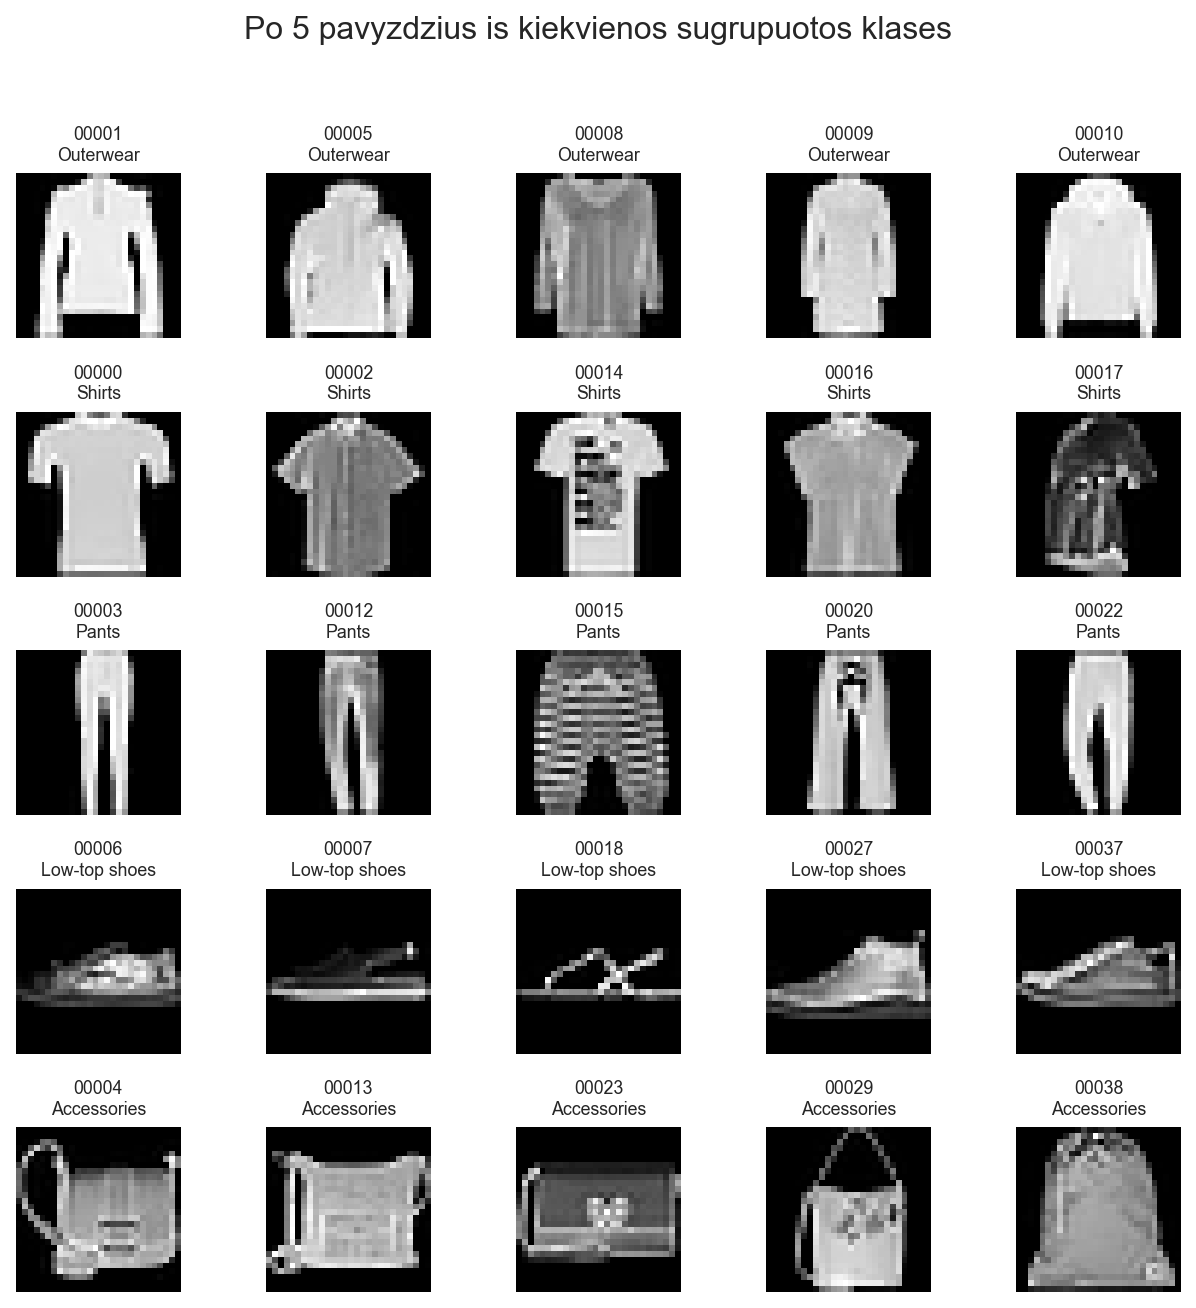

### Klasiu pasiskirstymo vizualizacija

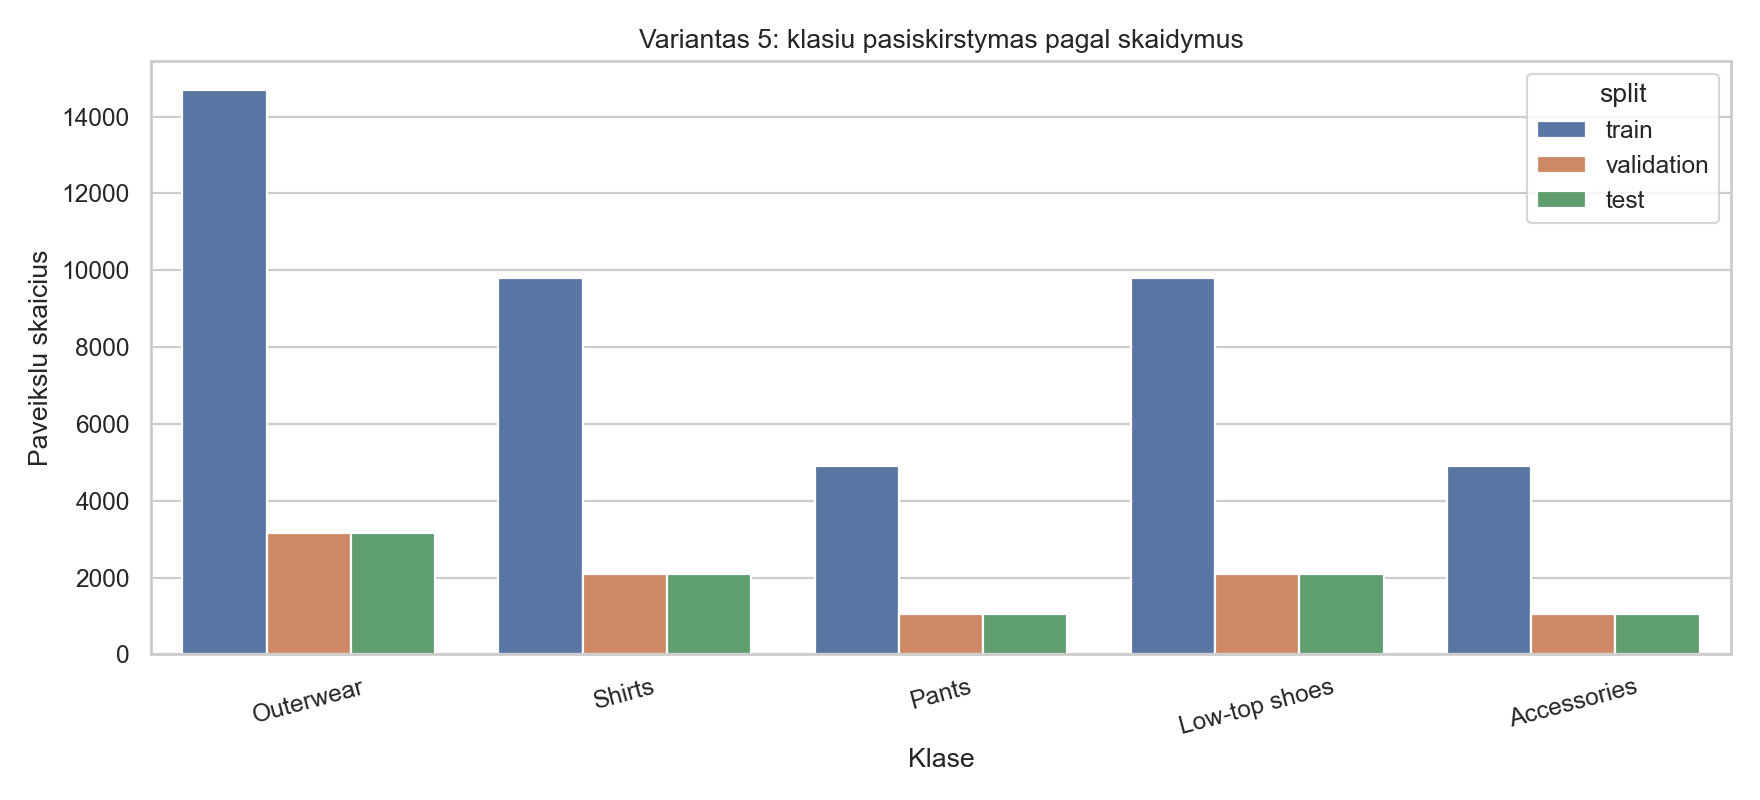

In [ ]:
display(Markdown("### Pavyzdiniai paveikslai"))
display(Image(filename=str(PROJECT_ROOT / RESULTS["dataset"]["example_images_plot"])))

display(Markdown("### Klasiu pasiskirstymo vizualizacija"))
display(Image(filename=str(PROJECT_ROOT / RESULTS["dataset"]["class_distribution_plot"])))


## Konvoliuciniu operaciju interpretacija

- **Convolution**: 3x3 branduoliai slenka per 28x28 pilko tono vaizda ir isgauna lokalinius bruozus, pavyzdziui, krastus, konturus ir teksturos fragmentus.
- **Stride**: pateiktose architekturose naudotas numatytasis `stride = 1`, todel po kiekvieno `Conv2D` bruozu zemelapis mazeja tik tiek, kiek leidzia branduolio dydis.
- **Padding**: pateiktuose variantuose naudotas `valid` tipo padding, todel vaizdo matmenys po konvoliuciju mazeja (`28 -> 26 -> 24` ir t. t.). Mano architekturoje naudotas `same`, kad mazu 28x28 paveikslu informacija butu prarandama letesniu tempu.
- **Pooling**: `MaxPooling2D` issaugo ryskiausius signalus, o `AveragePooling2D` labiau glotnina reprezentacija. Tai svarbu, nes uzduotyje lyginami skirtingi pooling tipai.


## Modeliu konfiguracija

Pateiktuose paveiksluose ne visos hiperparametru reiksmes buvo uzrasytos, todel priimtos sios darbinei realizacijai reikalingos prielaidos:

- visoms `Conv2D` ir pasleptoms `Dense` sluoksniu aktyvacijoms naudota `ReLU`;
- isejimo sluoksnyje naudota `Softmax`, nes yra 5 klases;
- `Variantas 7` `Dropout` sluoksniui pasirinkta `0.3`;
- optimizatorius: `Adam(learning_rate=1e-3)`;
- geriausia epocha parenkama pagal maziausia `validation loss`, taikant `EarlyStopping`.


### Bendras architekturu palyginimas

,display_name,params,epochs_ran,best_epoch,best_val_loss,best_val_accuracy,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,training_seconds
0,Variantas 8,225285,10,8,0.1413,0.9507,0.9510,0.9574,0.9587,0.9508,151.7640
1,Mano architektura,156965,7,5,0.1499,0.9443,0.9475,0.9552,0.9559,0.9477,526.4197
2,Variantas 7,93317,15,15,0.1715,0.9397,0.9356,0.9464,0.9466,0.9357,209.6018
3,Variantas 2,126981,13,11,0.1693,0.9372,0.9324,0.9455,0.9439,0.9326,170.9180


### Balanced accuracy palyginimas

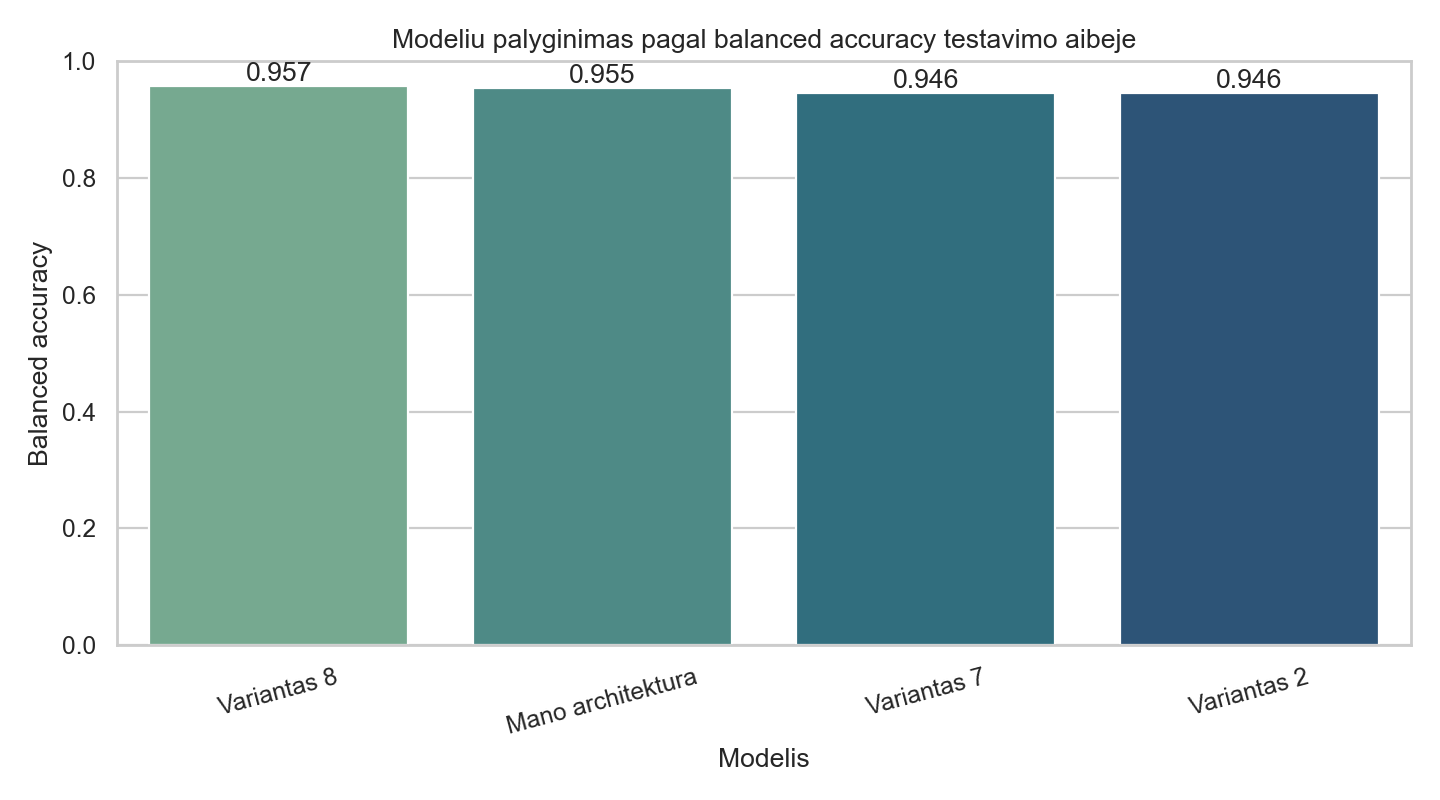

### Per-klasinio tikslumo silumos zemelapis

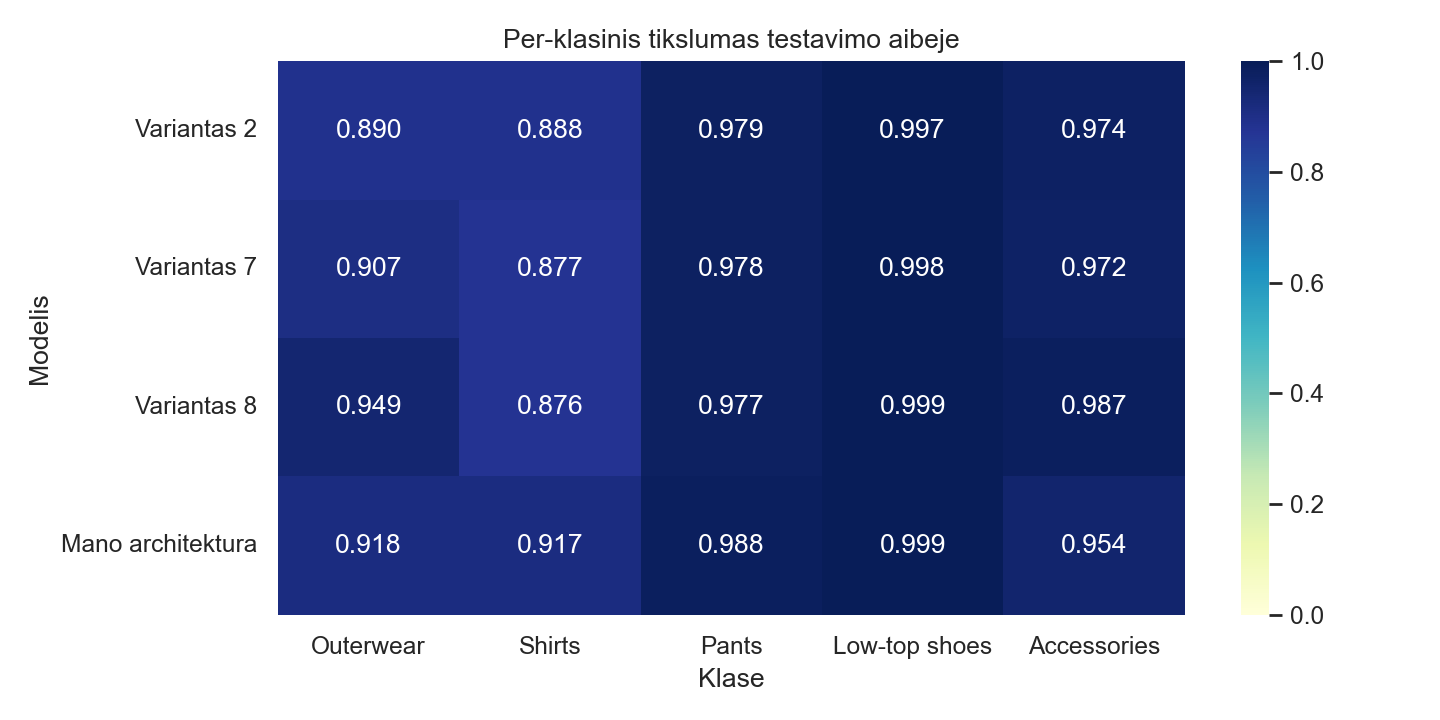

In [4]:
comparison_df = pd.read_csv(TABLES_DIR / "model_comparison.csv").sort_values(
    "test_balanced_accuracy", ascending=False
)
per_class_df = pd.read_csv(TABLES_DIR / "per_class_accuracy.csv")

display(Markdown("### Bendras architekturu palyginimas"))
display(comparison_df)

display(Markdown("### Balanced accuracy palyginimas"))
display(Image(filename=str(PROJECT_ROOT / RESULTS["artifacts"]["model_comparison_plot"])))

display(Markdown("### Per-klasinio tikslumo silumos zemelapis"))
display(Image(filename=str(PROJECT_ROOT / RESULTS["artifacts"]["per_class_accuracy_heatmap"])))


## Variantas 2

,display_name,params,epochs_ran,best_epoch,best_val_loss,best_val_accuracy,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,Variantas 2,126981,13,11,0.1693,0.9372,0.9324,0.9455,0.9439,0.9326


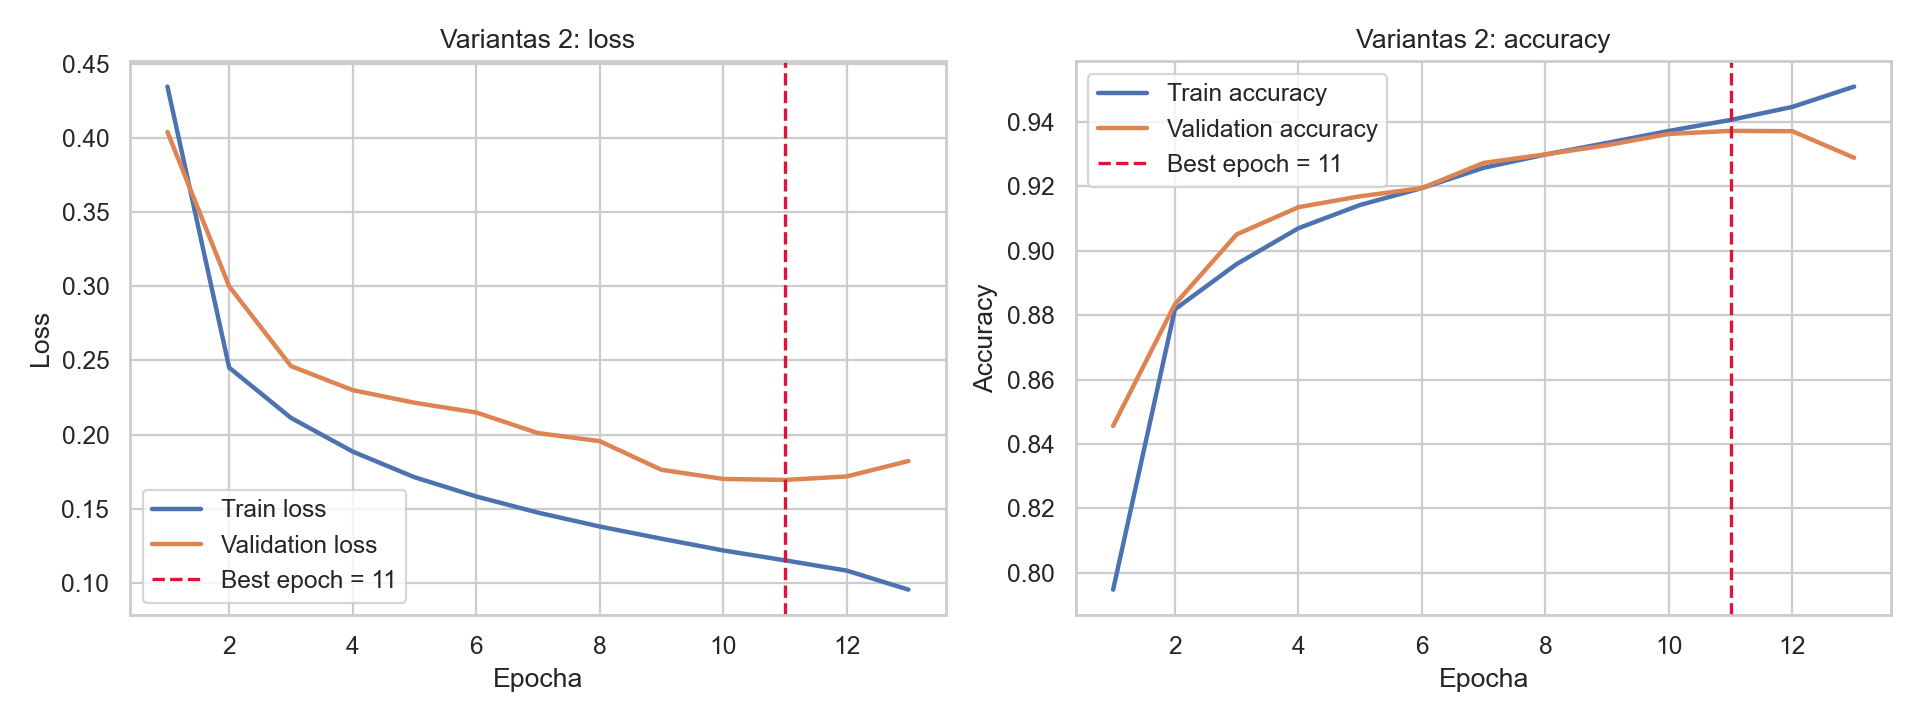

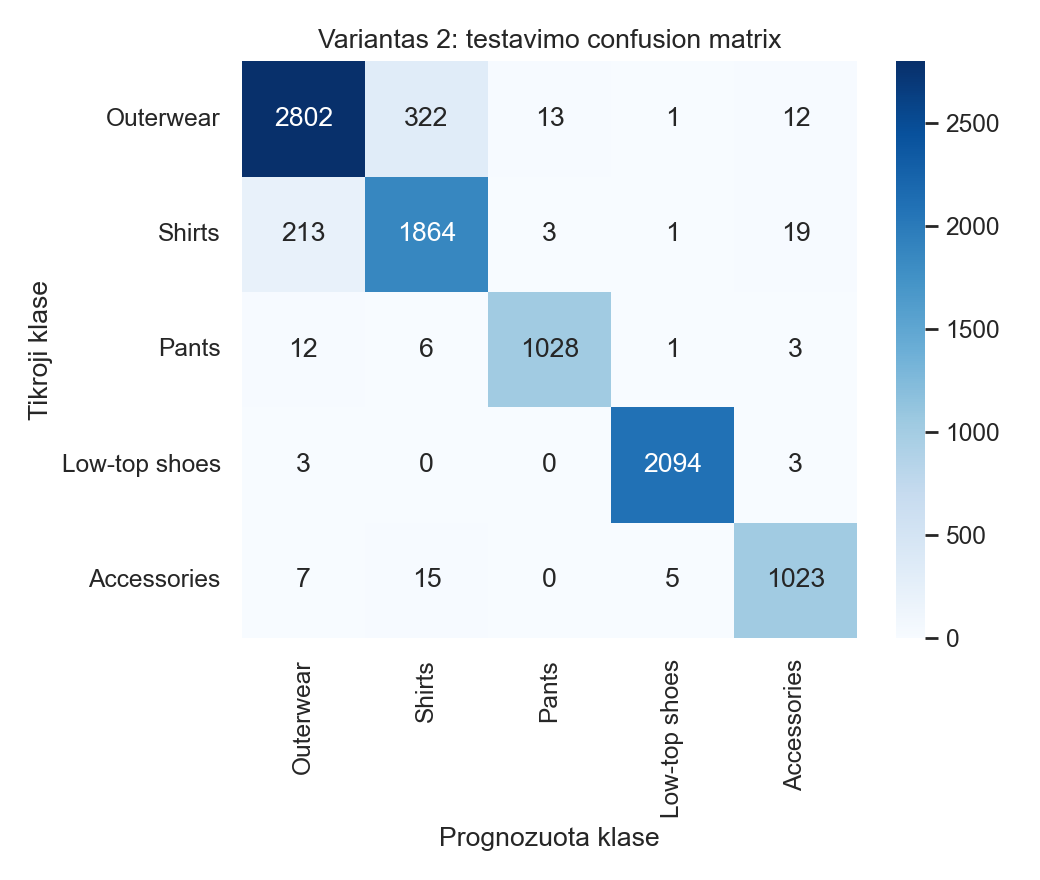

## Variantas 7

,display_name,params,epochs_ran,best_epoch,best_val_loss,best_val_accuracy,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,Variantas 7,93317,15,15,0.1715,0.9397,0.9356,0.9464,0.9466,0.9357


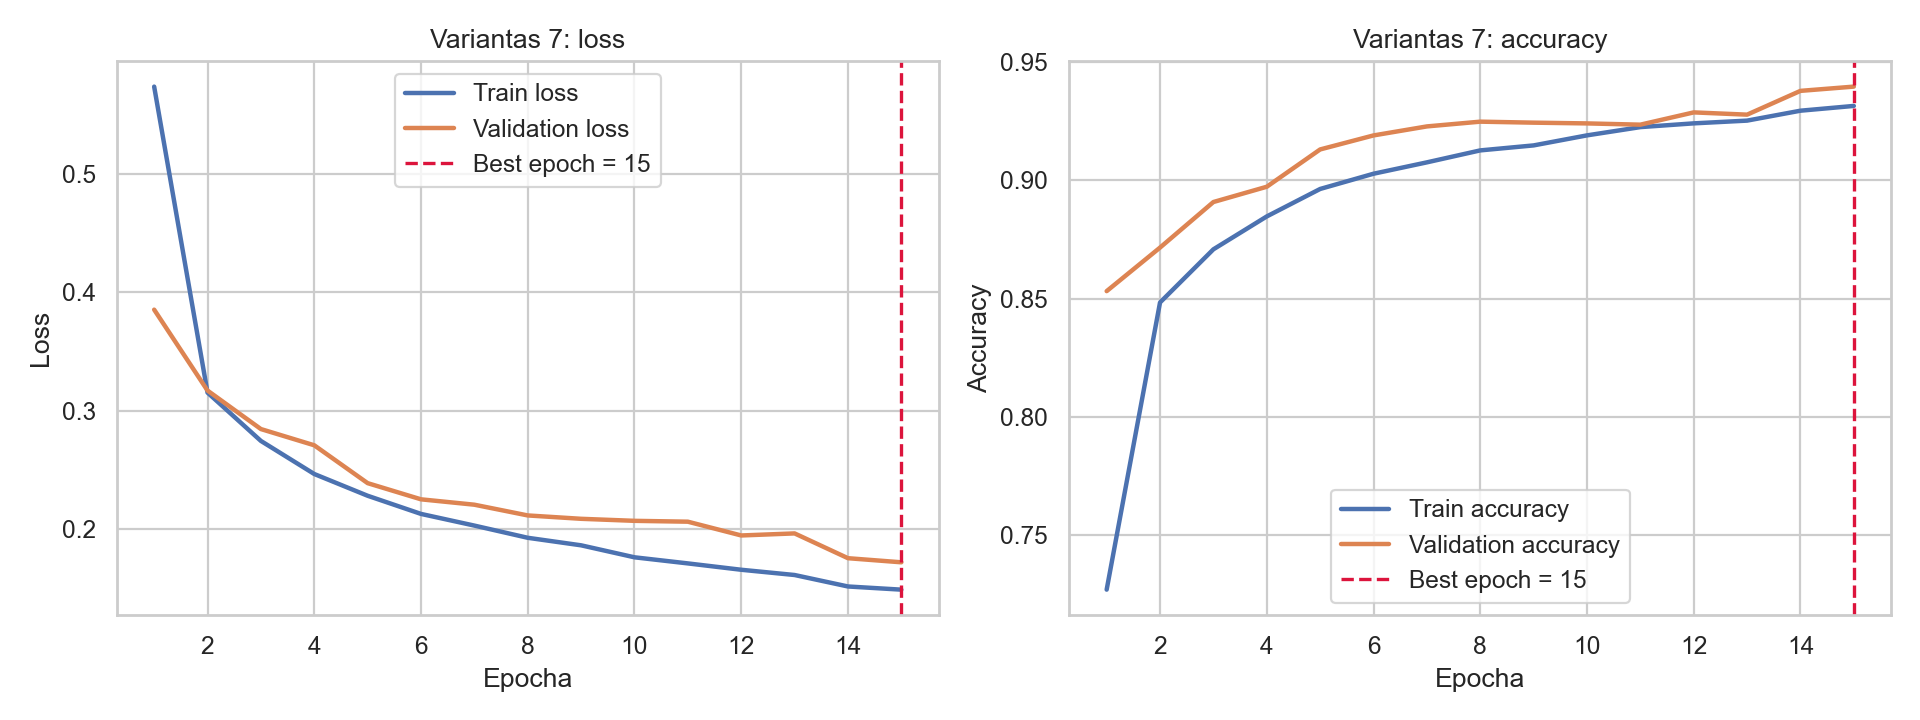

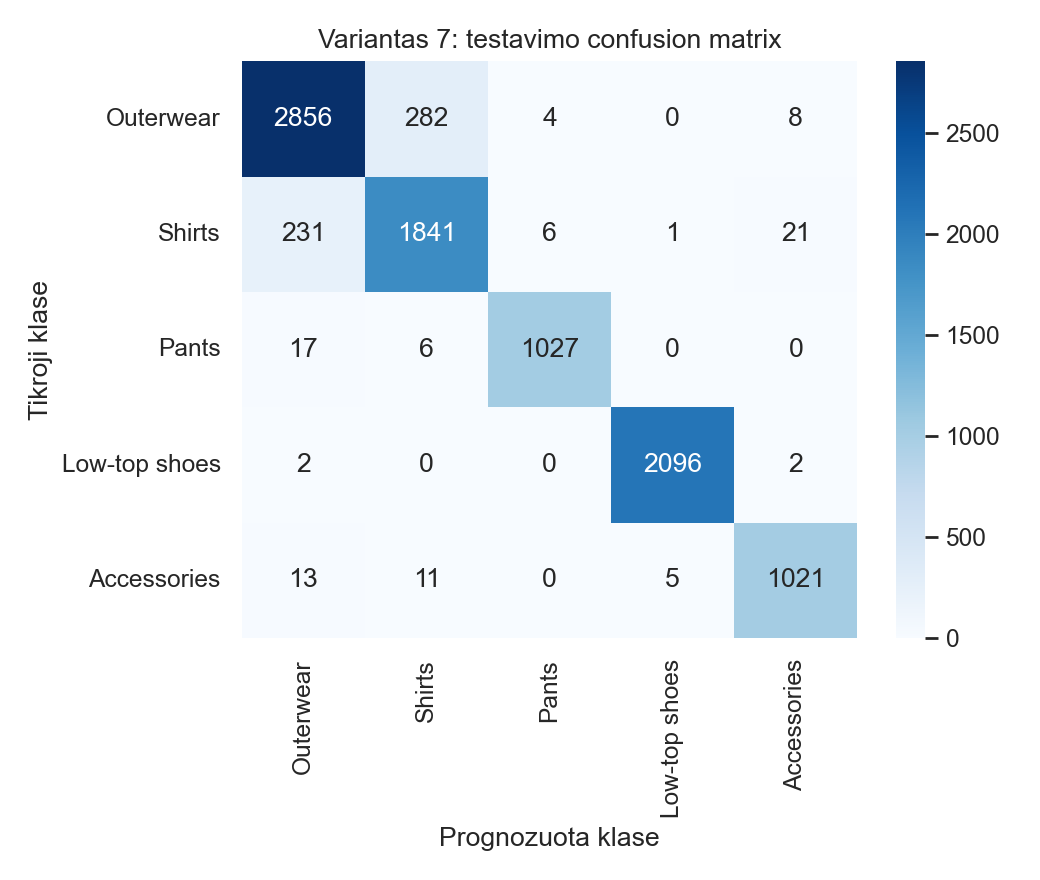

## Variantas 8

,display_name,params,epochs_ran,best_epoch,best_val_loss,best_val_accuracy,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,Variantas 8,225285,10,8,0.1413,0.9507,0.9510,0.9574,0.9587,0.9508


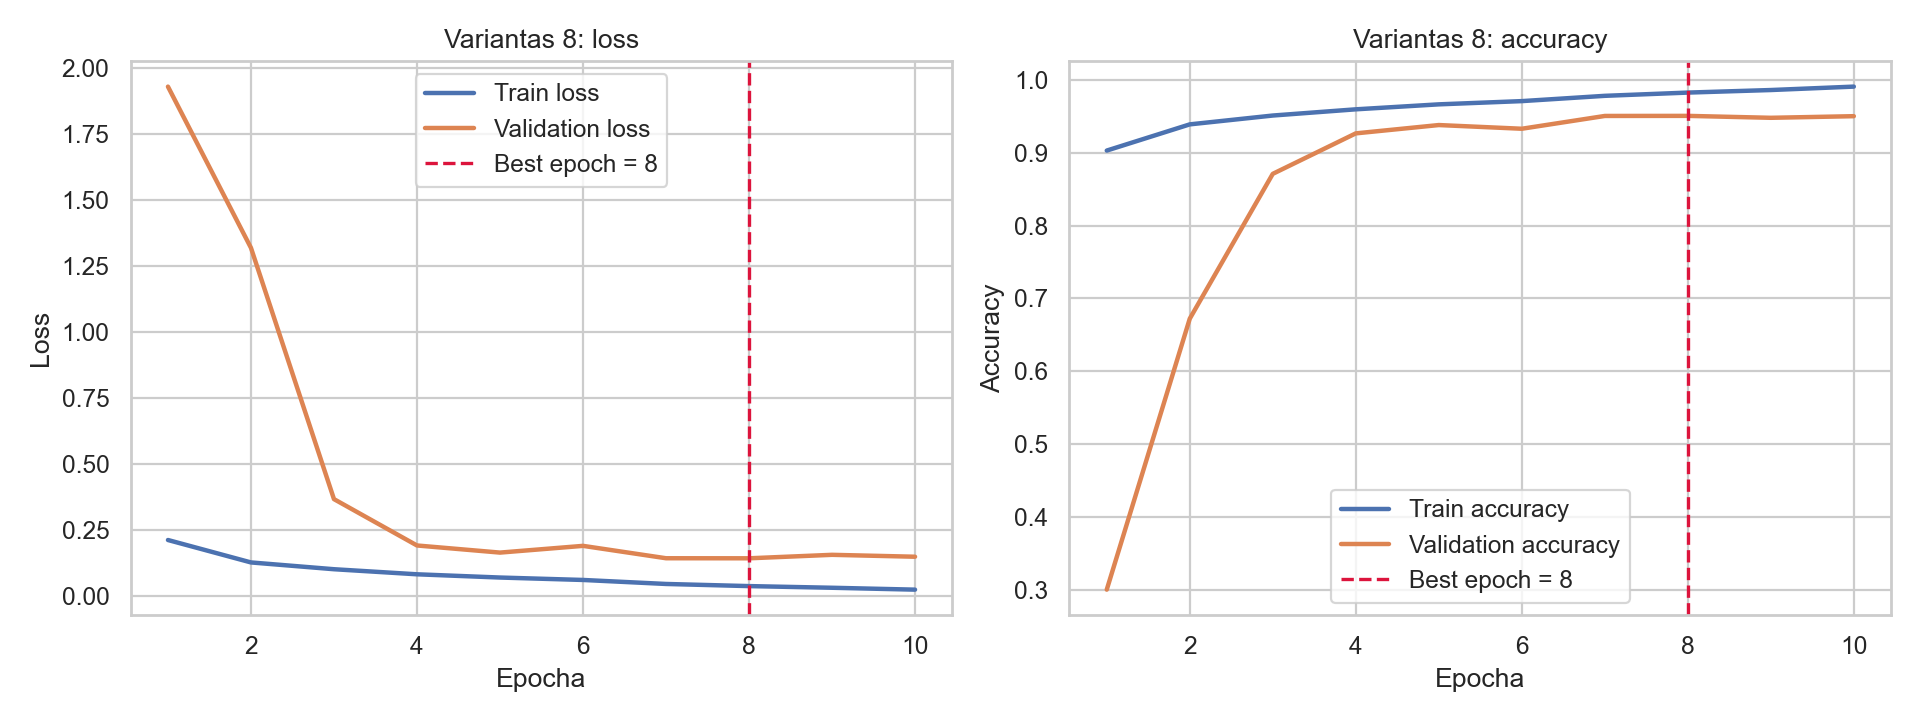

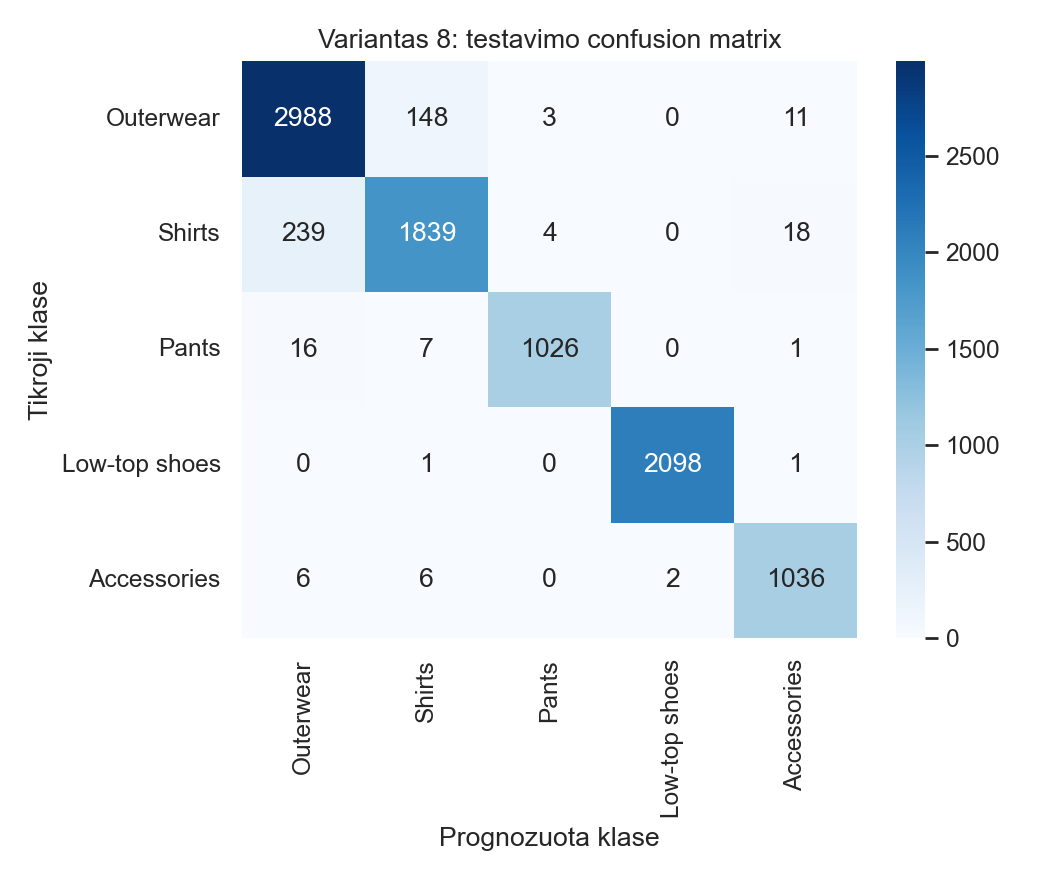

## Mano architektura

,display_name,params,epochs_ran,best_epoch,best_val_loss,best_val_accuracy,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,Mano architektura,156965,7,5,0.1499,0.9443,0.9475,0.9552,0.9559,0.9477


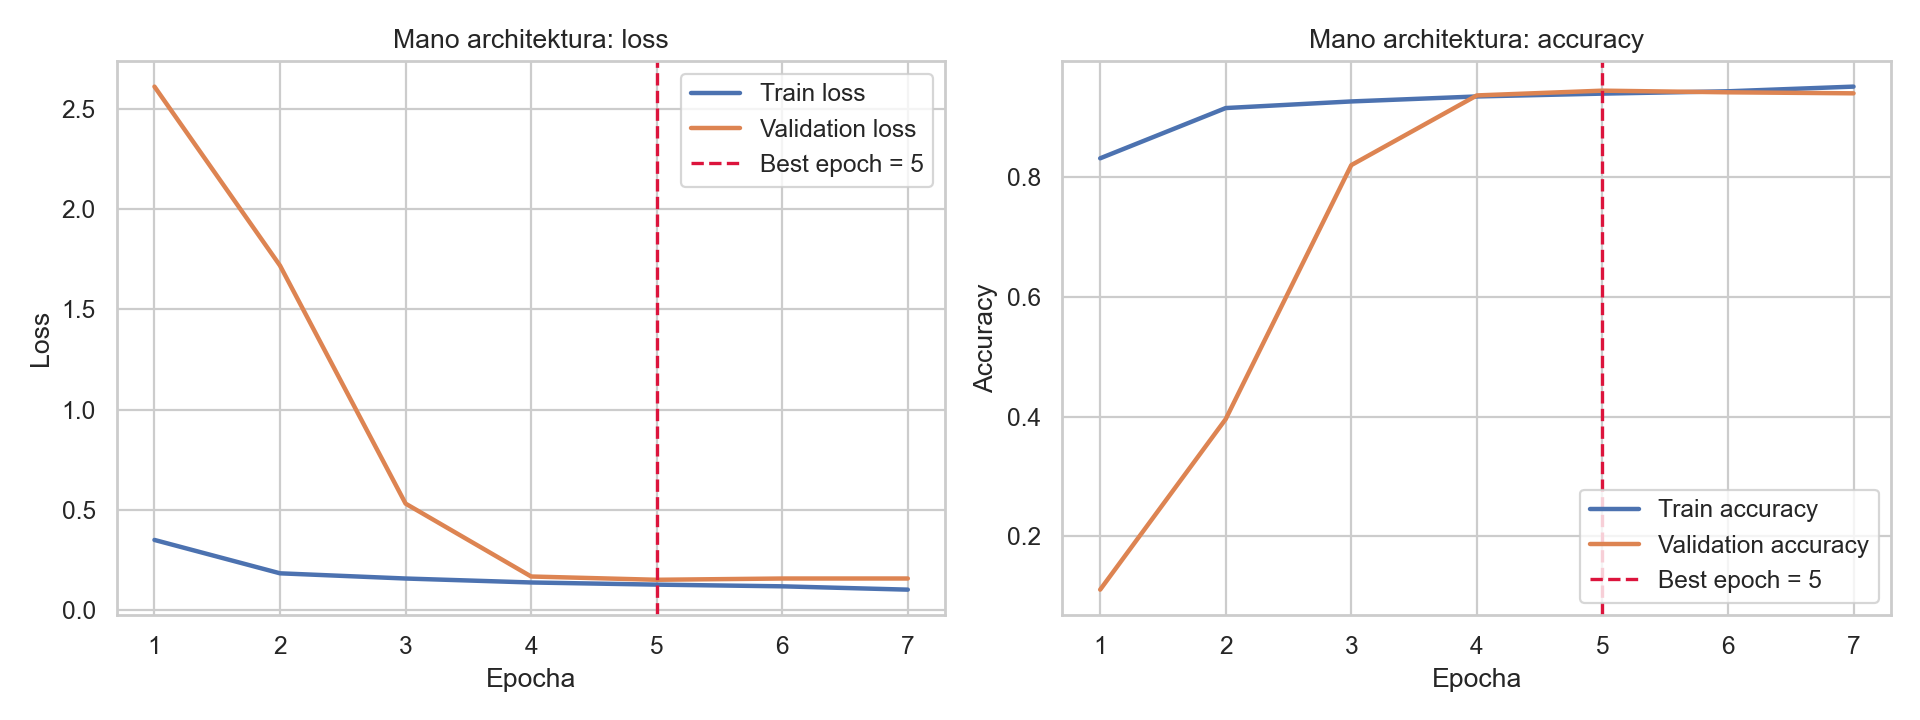

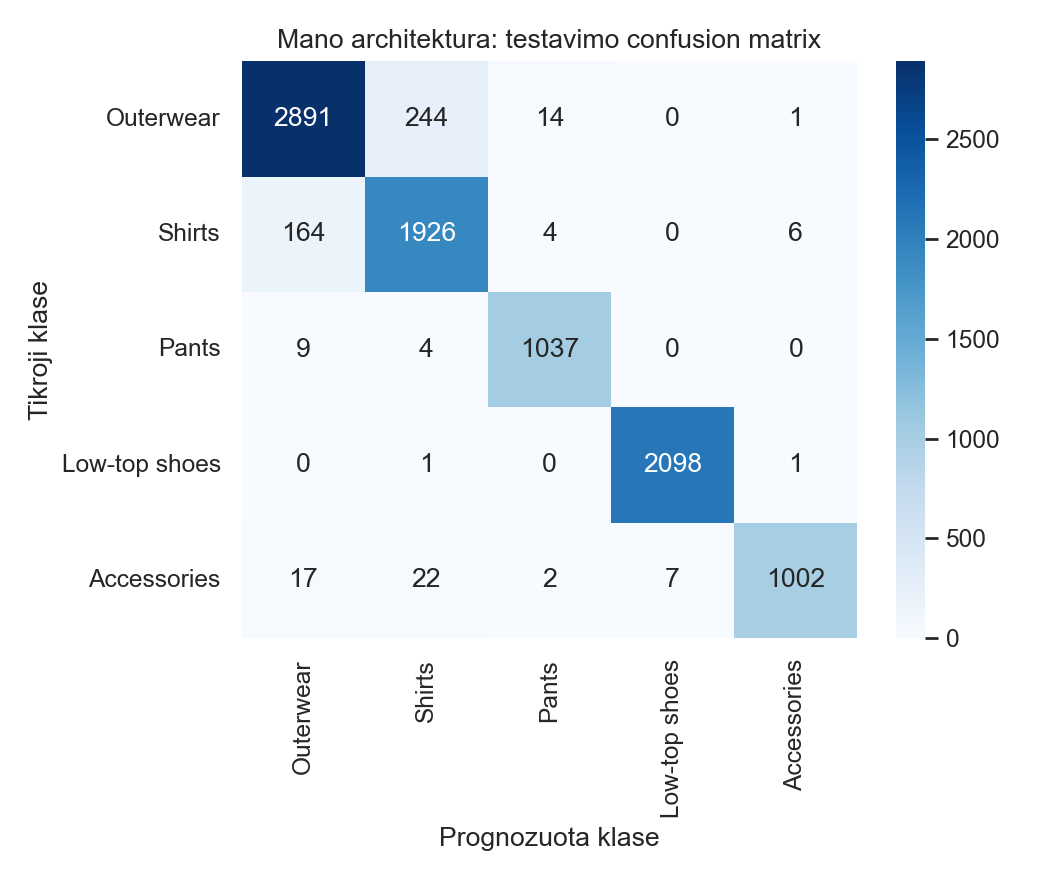

In [5]:
for model in RESULTS["main_models"]:
    metrics_df = pd.DataFrame([
        {
            "display_name": model["display_name"],
            "params": model["params"],
            "epochs_ran": model["epochs_ran"],
            "best_epoch": model["best_epoch"],
            "best_val_loss": model["best_val_loss"],
            "best_val_accuracy": model["best_val_accuracy"],
            "test_accuracy": model["test_accuracy"],
            "test_balanced_accuracy": model["test_balanced_accuracy"],
            "test_macro_f1": model["test_macro_f1"],
            "test_weighted_f1": model["test_weighted_f1"],
        }
    ])
    display(Markdown(f"## {model['display_name']}"))
    display(metrics_df)
    display(Image(filename=str(PROJECT_ROOT / model["history_plot"])))
    display(Image(filename=str(PROJECT_ROOT / model["confusion_matrix_plot"])))


## Mano architektura ir mazesnes imties tyrimas

Papildomai pasiulyta mano CNN architektura:

- du `Conv-BN-ReLU` blokai su `same` padding ir `MaxPooling`;
- antras analogiskas blokas su daugiau filtru;
- `Conv(128) + GlobalAveragePooling`;
- `Dense(128) + Dropout(0.3)`;
- `Softmax` klasifikatorius.

Ji pasirinkta tam, kad:

- mazi 28x28 vaizdai neprarastu informacijos per greitai;
- `BatchNormalization` stabilizuotu mokyma;
- `GlobalAveragePooling` sumazintu parametru skaiciu ir overfitting rizika;
- `Dropout` apsaugotu nuo per didelio prisitaikymo prie treniravimo aibes.

Mazesnes imties analizei naudoti **pirmi N paveikslu pagal failo pavadinima abeceles tvarka** is `train` aibes ir `Stratified K-Fold (k=3)`.


### 3-fold CV suvestine pagal imties dydi

,sample_size,mean_accuracy,std_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,std_macro_f1,mean_best_epoch
0,5000,0.2274,0.0115,0.2206,0.0208,0.1067,0.0333,1.0000
1,10000,0.6480,0.0742,0.7081,0.0510,0.6779,0.0678,10.0000
2,20000,0.8781,0.0538,0.9104,0.0292,0.8947,0.0538,9.3333
3,30000,0.9247,0.0078,0.9422,0.0064,0.9379,0.0048,9.3333


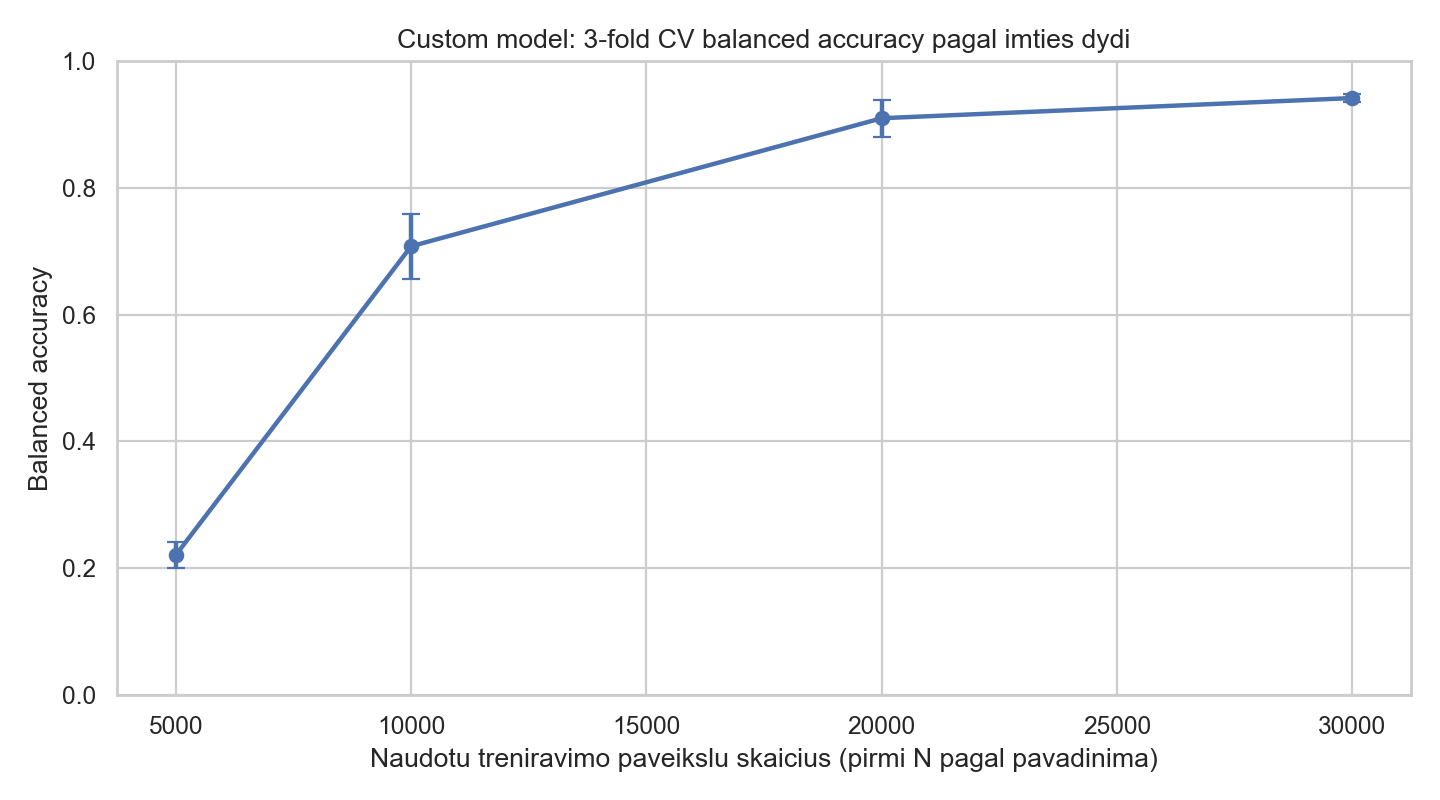

### Pilnos ir sumazintos imties palyginimas

,variantas,train_size,test_accuracy,test_balanced_accuracy,test_macro_f1
0,Pilna mano architektura,44100,0.9475,0.9552,0.9559
1,"Mano architektura, pirmi 30000",30000,0.9467,0.9547,0.9535


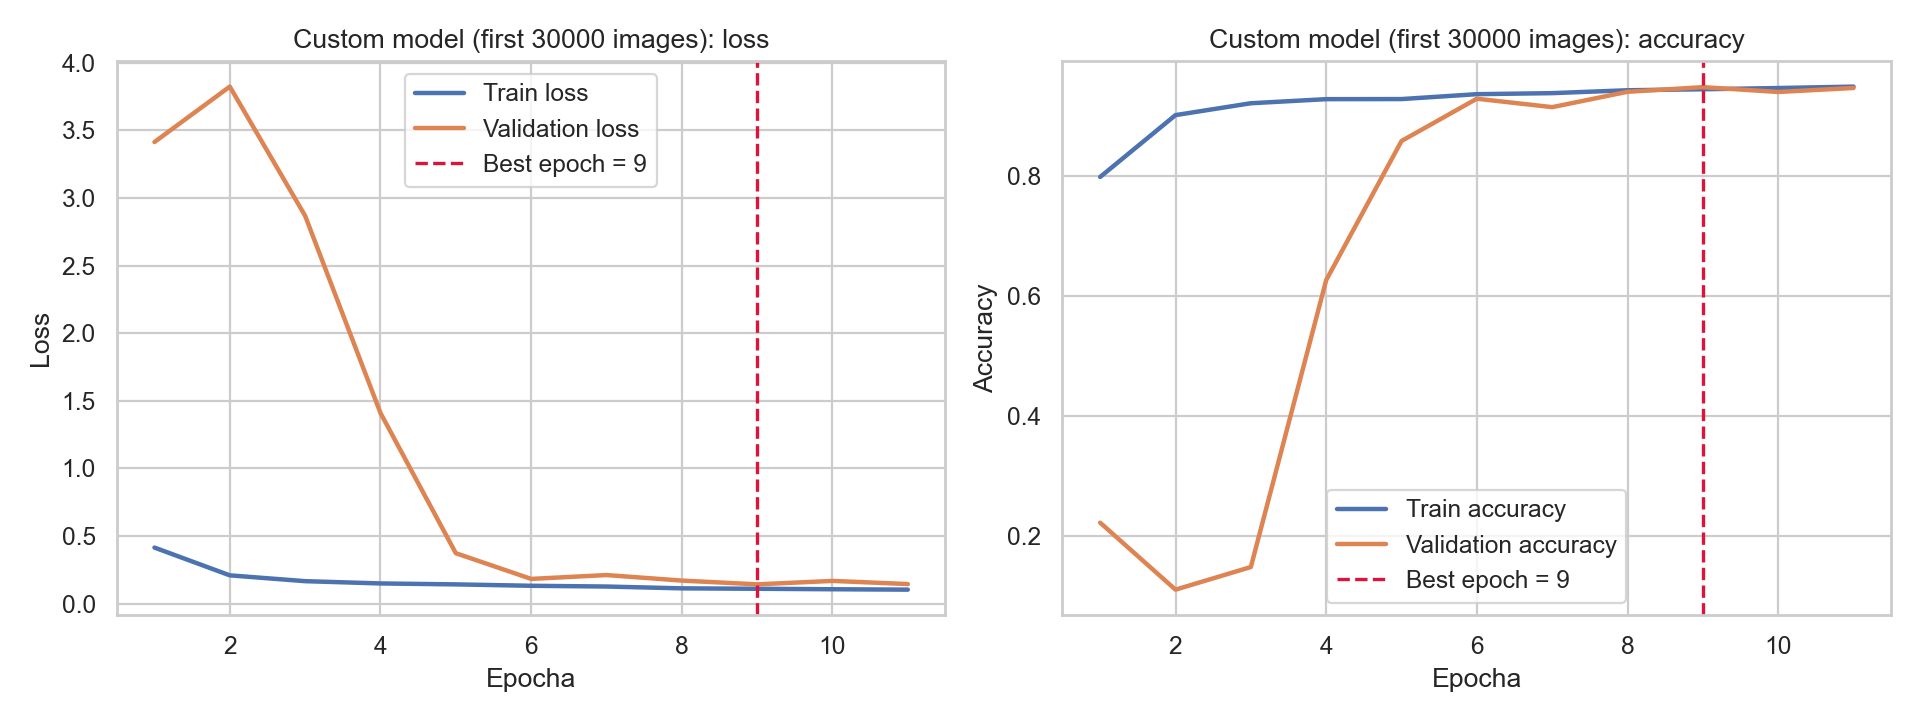

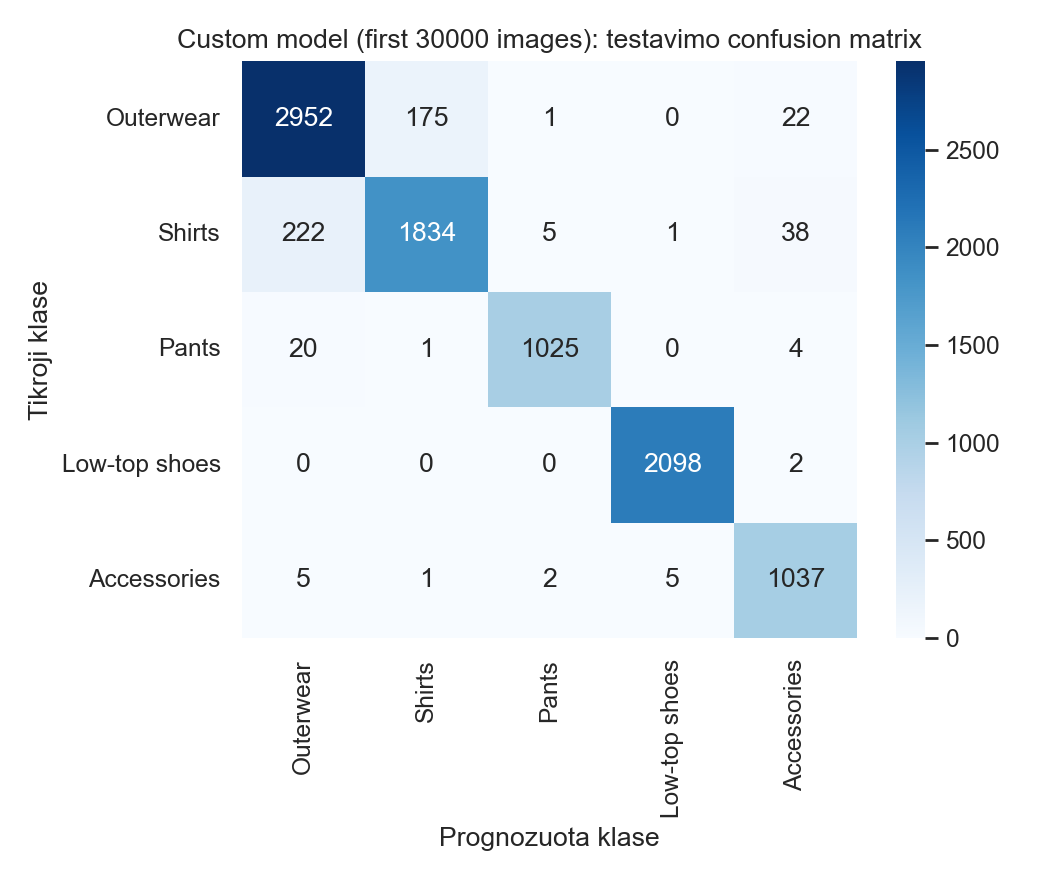

In [6]:
sample_size_summary = pd.read_csv(TABLES_DIR / "sample_size_cv_summary.csv")
display(Markdown("### 3-fold CV suvestine pagal imties dydi"))
display(sample_size_summary)
display(Image(filename=str(PROJECT_ROOT / RESULTS["sample_size_study"]["cv_plot"])))

reduced = RESULTS["sample_size_study"]["reduced_model_result"]
full_custom = next(model for model in RESULTS["main_models"] if model["model_key"] == "custom_model")
full_train_size = sum(RESULTS["dataset"]["split_counts"]["train"].values())
comparison = pd.DataFrame(
    [
        {
            "variantas": "Pilna mano architektura",
            "train_size": full_train_size,
            "test_accuracy": full_custom["test_accuracy"],
            "test_balanced_accuracy": full_custom["test_balanced_accuracy"],
            "test_macro_f1": full_custom["test_macro_f1"],
        },
        {
            "variantas": f"Mano architektura, pirmi {RESULTS['sample_size_study']['acceptable_size']}",
            "train_size": RESULTS["sample_size_study"]["acceptable_size"],
            "test_accuracy": reduced["test_accuracy"],
            "test_balanced_accuracy": reduced["test_balanced_accuracy"],
            "test_macro_f1": reduced["test_macro_f1"],
        },
    ]
)
display(Markdown("### Pilnos ir sumazintos imties palyginimas"))
display(comparison)
display(Image(filename=str(PROJECT_ROOT / reduced["history_plot"])))
display(Image(filename=str(PROJECT_ROOT / reduced["confusion_matrix_plot"])))


In [7]:
best_presented = RESULTS["conclusions"]["best_presented_model"]
best_presented_score = RESULTS["conclusions"]["best_presented_balanced_accuracy"]
custom_score = RESULTS["conclusions"]["custom_model_balanced_accuracy"]
reduced_score = RESULTS["conclusions"]["reduced_custom_balanced_accuracy"]
acceptable_size = RESULTS["conclusions"]["acceptable_sample_size"]
train_size_full = sum(RESULTS["dataset"]["split_counts"]["train"].values())
if custom_score > best_presented_score:
    custom_statement = "Mano architektura buvo geresne uz visas pateiktas."
else:
    custom_statement = "Mano architektura buvo konkurencinga pateiktoms architekturoms, bet nevirsijo geriausio pateikto varianto."

final_md = f'''
## Galutines isvados

1. **Duomenu paruosimas.** Pagal Varianta 5 is pradinio rinkinio paliktos 5 sugrupuotos klases, o skaidymas atliktas stratified principu i `train`, `validation` ir `test` aibes. Tai leido isvengti pernelyg stipriu proporciju svyravimu tarp skaidymu.

2. **Klasiu disbalansas yra svarbus.** `Outerwear` klase sudaryta is triju originaliu klasiu, todel jos pavyzdziu daugiausia. Vien bendro `accuracy` nepakanka, todel modeliai lyginti ir pagal `balanced accuracy`, `macro F1` bei per-klasini tiksluma.

3. **Is pateiktu architekturu geriausia pasirode {best_presented}.** Jos `balanced accuracy` testavimo aibeje sieke **{best_presented_score:.4f}**. Tai rodo, kad sio uzdavinio sprendimui svarbu ne tik sluoksniu skaicius, bet ir tai, kaip greitai mazina vaizdo matmenis pooling sluoksniai bei kiek parametru turi klasifikatoriaus galva.

4. **{custom_statement}** Pilnos imties atveju ji pasieke **{custom_score:.4f}** `balanced accuracy` naudodama **{train_size_full}** treniravimo paveikslu. Privalumas atsirado del `same padding`, `BatchNormalization`, saikingo `Dropout` ir `GlobalAveragePooling`, kurie padejo geriau islaikyti informacija mazuose 28x28 vaizduose.

5. **Priimtina mazesne treniravimo imtis.** Pagal 3-fold CV kriteriju maziausia priimtina imtimi pasirinkta **pirmi {acceptable_size} paveikslu pagal pavadinima**. Tokia imtis dar islaike auksta kokybe, o sumazintos imties mano modelis testavimo aibeje pasieke **{reduced_score:.4f}** `balanced accuracy`.

6. **Praktine rekomendacija.** Jei svarbiausia yra kokybe, verta naudoti mano architektura su pilna imtimi. Jei svarbi mokymo trukme ir pakanka labai artimo rezultato, galima naudoti pirmus {acceptable_size} treniravimo paveikslus pagal pavadinima ir ta pacia architektura.
'''

display(Markdown(final_md))



## Galutines isvados

1. **Duomenu paruosimas.** Pagal Varianta 5 is pradinio rinkinio paliktos 5 sugrupuotos klases, o skaidymas atliktas stratified principu i `train`, `validation` ir `test` aibes. Tai leido isvengti pernelyg stipriu proporciju svyravimu tarp skaidymu.

2. **Klasiu disbalansas yra svarbus.** `Outerwear` klase sudaryta is triju originaliu klasiu, todel jos pavyzdziu daugiausia. Vien bendro `accuracy` nepakanka, todel modeliai lyginti ir pagal `balanced accuracy`, `macro F1` bei per-klasini tiksluma.

3. **Is pateiktu architekturu geriausia pasirode Variantas 8.** Jos `balanced accuracy` testavimo aibeje sieke **0.9574**. Tai rodo, kad sio uzdavinio sprendimui svarbu ne tik sluoksniu skaicius, bet ir tai, kaip greitai mazina vaizdo matmenis pooling sluoksniai bei kiek parametru turi klasifikatoriaus galva.

4. **Mano architektura buvo konkurencinga pateiktoms architekturoms, bet nevirsijo geriausio pateikto varianto.** Pilnos imties atveju ji pasieke **0.9552** `balanced accuracy` naudodama **44100** treniravimo paveikslu. Privalumas atsirado del `same padding`, `BatchNormalization`, saikingo `Dropout` ir `GlobalAveragePooling`, kurie padejo geriau islaikyti informacija mazuose 28x28 vaizduose.

5. **Priimtina mazesne treniravimo imtis.** Pagal 3-fold CV kriteriju maziausia priimtina imtimi pasirinkta **pirmi 30000 paveikslu pagal pavadinima**. Tokia imtis dar islaike auksta kokybe, o sumazintos imties mano modelis testavimo aibeje pasieke **0.9547** `balanced accuracy`.

6. **Praktine rekomendacija.** Jei svarbiausia yra kokybe, verta naudoti mano architektura su pilna imtimi. Jei svarbi mokymo trukme ir pakanka labai artimo rezultato, galima naudoti pirmus 30000 treniravimo paveikslus pagal pavadinima ir ta pacia architektura.
